# MODELE HMM

## PHASE 1 : Entraînement initial du HMM

In [1]:
# Import des biblio
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

In [2]:
# === 1. Charger ta base ===
df = pd.read_excel("rendements_portefeuilles_corr (1).xlsx", engine='openpyxl')

In [5]:
df

,Value (i)Booktomarket global,Value(ii) ResultNet-Cours,Value(iii) CA-cours,Quality(i) Levier Financier,Quality(ii) ROE,Qaulity(iii) ROA,Growth(i) Divident yield,Volatilité(i) la variance,Momentum(i) Rendement Journalier,Mom(ii) 6 Month Price Momentum,Liquidité(i) volume,Risk(i) Beta,Size(i) Capitalisation boursièr
Date,,,,,,,,,,,,,
2017-01-02,0.006229,-0.023467,0.003443,-0.007581,-0.023327,-0.020363,0.008558,0.009708,0.073117,-0.000109,-0.012280,0.011023,-0.029930
2017-01-03,-0.011626,-0.020430,-0.007099,0.003707,-0.016910,-0.007821,-0.026523,0.012239,0.005696,-0.010157,-0.003184,-0.003167,-0.026785
2017-01-04,-0.005048,0.004443,-0.011426,0.004544,0.011264,-0.005189,-0.011648,0.007660,-0.006529,0.016328,0.003347,-0.007989,-0.037301
2017-01-05,0.002251,0.008754,0.018090,-0.001161,-0.009592,-0.001811,-0.007446,-0.004269,0.008382,0.005712,0.007644,-0.017828,0.003148
2017-01-06,0.018010,-0.003940,-0.000840,-0.017210,-0.001219,0.003507,0.009459,-0.023642,-0.002915,-0.001831,-0.009003,0.007016,0.023760
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-02,-0.006213,0.004333,-0.006512,0.002644,-0.002669,0.006086,-0.009616,0.015276,0.071481,0.003800,0.002379,-0.036708,0.018272
2025-06-03,0.007479,0.000028,0.001839,-0.006890,0.000220,-0.002434,-0.026245,0.006143,0.001381,0.000130,0.000559,-0.009168,0.002558
2025-06-04,0.004243,0.013314,-0.012870,-0.004142,0.005593,0.014753,-0.006033,0.001570,0.018160,0.013385,0.000015,-0.014439,0.007261


In [3]:
# === 2. Préparer les données ===
# S'assurer que les dates sont bien dans l'index (si tu as une colonne Date)
df.index = pd.to_datetime(df['Date'])  # si applicable
df = df.drop(columns=['Date'])         # si applicable


In [4]:
# Étape 1 : Sélection de la période d'entraînement
train_end = 1852
df_train = df.iloc[:train_end].copy()

In [6]:
# Étape 2 : Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train)

In [7]:
# Étape 3 : Entraînement du modèle HMM (2 états cachés)
hmm_model = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
hmm_model.fit(X_train)

,n_components,2
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [8]:
# Étape 4 : Prédiction des états cachés
hidden_states = hmm_model.predict(X_train)

In [9]:
# Étape 5 : Stockage des régimes
df_regimes_hmm = pd.DataFrame({
    'Date': df_train.index,
    'Regime_brut': hidden_states
}).set_index('Date')

In [10]:
df_regimes_hmm['Regime_brut'].value_counts()

Regime_brut
0    1514
1     338
Name: count, dtype: int64

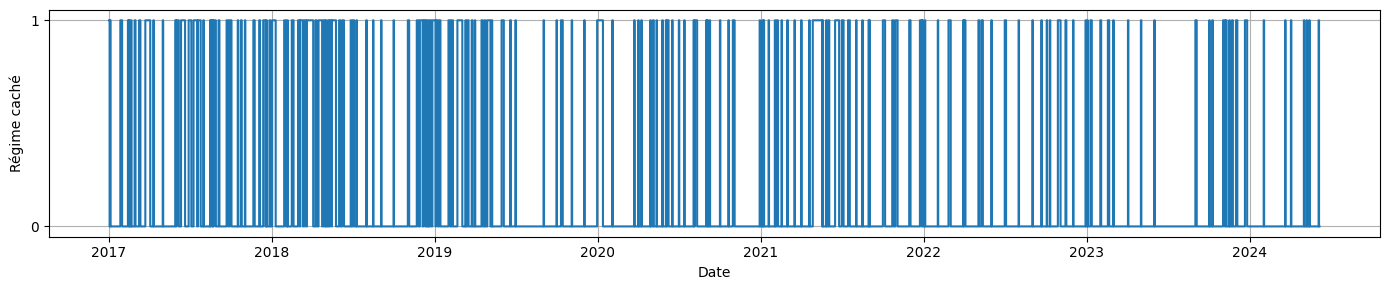

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Suppose que tu as déjà obtenu ceci :
# df_regimes_hmm = DataFrame avec colonnes ['Regime_brut'] et Date en index

plt.figure(figsize=(14, 3))
plt.plot(df_regimes_hmm.index, df_regimes_hmm['Regime_brut'], drawstyle='steps-post')
plt.title("")
plt.xlabel("Date")
plt.ylabel("Régime caché")
plt.yticks([0, 1])
plt.grid(True)
plt.tight_layout()
plt.show()


## PHASE 2 : Ré-entraînement jour par jou

In [12]:
# Import des biblio
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

In [13]:
# Paramètres
start_retrain = 1853
end_retrain = 2107
#start_idx = 1853          # début du réentraînement (02/01/2023)
#end_idx = 2107 
d = 5  # Nombre de jours de confirmation


In [14]:
# Initialisation
regimes_bruts = []
dates_retrain = df.index[start_retrain:end_retrain]
scaler = StandardScaler()

In [15]:
# Réentraînement jour par jour
for t in range(start_retrain, end_retrain):
    df_window = df.iloc[:t]
    X_window = scaler.fit_transform(df_window.select_dtypes(include=[np.number]))

    model = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
    model.fit(X_window)
    z = model.predict(X_window)[-1]  # Dernier état estimé
    regimes_bruts.append(z)

In [16]:
# Construction du DataFrame des régimes bruts
df_regimes_hmm_rt = pd.DataFrame({
    'Date': dates_retrain,
    'Regime_brut': regimes_bruts
}).set_index('Date')

In [17]:
# Application de la règle de confirmation (d=5)
regimes_confirmes = []
dernier_regime_confirme = regimes_bruts[0]

for i in range(len(regimes_bruts)):
    if i < d:
        regimes_confirmes.append(dernier_regime_confirme)
        continue
    derniere_fenetre = regimes_bruts[i-d+1:i+1]
    if all(r == derniere_fenetre[0] for r in derniere_fenetre):
        dernier_regime_confirme = derniere_fenetre[0]
    regimes_confirmes.append(dernier_regime_confirme)

In [18]:
# Ajout des régimes confirmés
df_regimes_hmm_rt['Regime_confirme'] = regimes_confirmes

In [19]:
df_regimes_hmm_rt['Regime_confirme'].value_counts()

Regime_confirme
0    157
1     97
Name: count, dtype: int64

## PHASE 3 : Construction des portefeuilles factorielles dynamiques

### Règle de déclenchement

In [48]:
# Début et fin de la phase de test + réentraînement
start_test = 1853
end_test = 2107  # jusqu'à 2106 inclus
step = 22  # début de mois = tous les 22 jours

# Index relatifs dans df_facteurs
debut_mois_idx = list(range(start_test, end_test, step))

# Dates correspondantes
dates_debut_mois = df.index[debut_mois_idx]

# Règle de déclenchement : vérifier changement de régime sur les 22 jours précédents
reallocation_flags = []

for i, t in enumerate(debut_mois_idx):
    if i == 0:
        reallocation_flags.append(False)
        continue

    # Plage dans df_regimes_hmm_rt : relative à t - start_test
    debut = debut_mois_idx[i - 1] - start_test
    fin = debut_mois_idx[i] - start_test

    fenetre_regimes = df_regimes_hmm_rt.iloc[debut:fin]['Regime_confirme']
    changement = fenetre_regimes.diff().fillna(0) != 0
    reallocation_flags.append(changement.any())

# Initialisation de la colonne "Declencher_reallocation"
df_regimes_hmm_rt['Declencher_reallocation'] = False

for date, flag in zip(dates_debut_mois, reallocation_flags):
    if date in df_regimes_hmm_rt.index:
        df_regimes_hmm_rt.loc[date, 'Declencher_reallocation'] = flag


### Max Return

In [ ]:
valeurs_maxreturn = [1.0]
rendements_maxreturn = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    # Vérifie si c’est un début de mois
    if (t - 1853) % 22 == 0:
        debut_mois = True
    else:
        debut_mois = False

    # Vérifie s’il y a eu changement de régime le mois précédent
    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        # On réalloue
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        poids_actuels = mu / mu.sum()  # Poids bruts
        poids_actuels = np.clip(poids_actuels, 0, 0.8)
        poids_actuels /= poids_actuels.sum()  # Re-normalisation

    if poids_actuels is None:
        rendements_maxreturn.append(0)
        valeurs_maxreturn.append(valeurs_maxreturn[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_maxreturn.append(rendement)
    valeurs_maxreturn.append(valeurs_maxreturn[-1] * (1 + rendement))

# Résultat final
df_backtest_maxreturn_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_maxreturn,
    'Valeur': valeurs_maxreturn[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)


📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :


,Facteur,Poids final
0,Value (i)Booktomarket global,0.084374
1,Value(ii) ResultNet-Cours,0.197274
2,Value(iii) CA-cours,0.139027
3,Quality(i) Levier Financier,0.000000
4,Quality(ii) ROE,0.142731
5,Qaulity(iii) ROA,0.089767
6,Growth(i) Divident yield,0.176100
7,Volatilité(i) la variance,0.013486
8,Momentum(i) Rendement Journalier,0.000000
9,Mom(ii) 6 Month Price Momentum,0.000000


: 

In [23]:
df_backtest_maxreturn_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,-0.003943,0.771362
2025-06-03,-0.004348,0.768008
2025-06-04,0.001384,0.769072


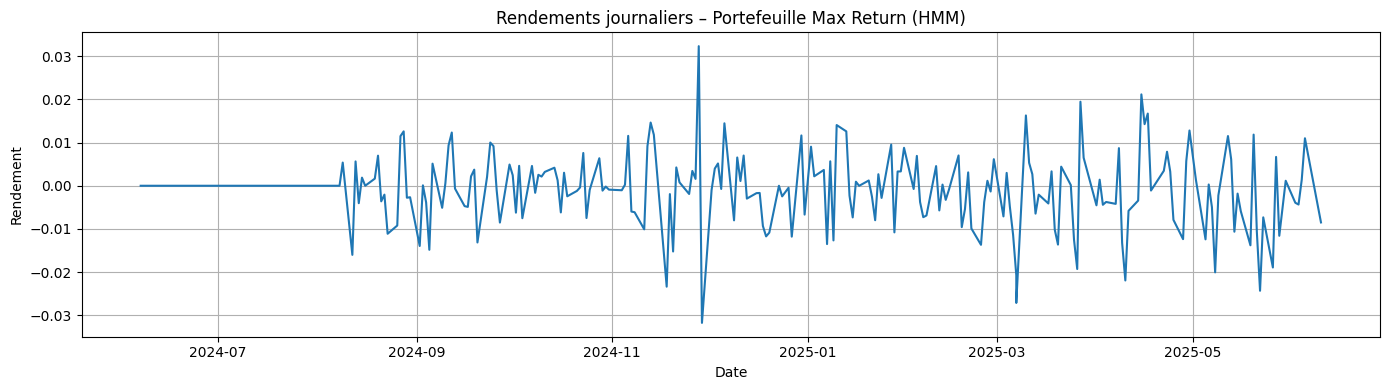

In [24]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_maxreturn_hmm.index, df_backtest_maxreturn_hmm['Rendement'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Max Return (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

### Dynamique

In [ ]:
valeurs_dyn = [1.0]
rendements_dyn = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    # Début de mois
    debut_mois = (t - 1853) % 22 == 0

    # Changement de régime le mois précédent ?
    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        mu_abs = np.abs(mu)
        poids_actuels = mu_abs / mu_abs.sum()

    if poids_actuels is None:
        rendements_dyn.append(0)
        valeurs_dyn.append(valeurs_dyn[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_dyn.append(rendement)
    valeurs_dyn.append(valeurs_dyn[-1] * (1 + rendement))

df_backtest_dyn_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_dyn,
    'Valeur': valeurs_dyn[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)


In [26]:
df_backtest_dyn_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.021935,1.107655
2025-06-03,-0.002103,1.105326
2025-06-04,0.007567,1.113690


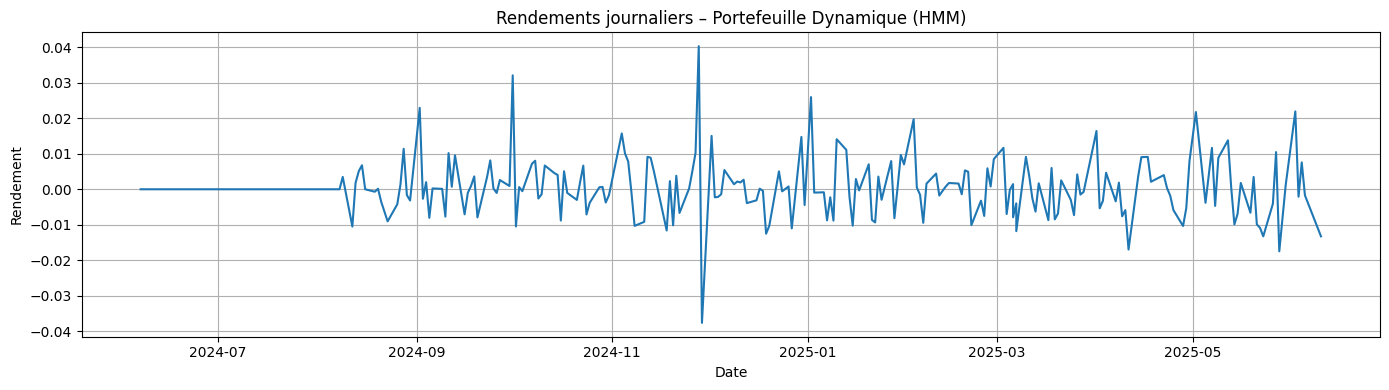

In [27]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_dyn_hmm.index, df_backtest_dyn_hmm['Rendement'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Dynamique (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

### Max Sharpe

In [ ]:
def max_sharpe_portfolio(mu, cov, rf=0.0):
    excess_returns = mu - rf
    try:
        inv_cov = np.linalg.pinv(cov)
        w = inv_cov @ excess_returns
        w = np.maximum(w, 0)
        if np.sum(w) == 0 or np.any(np.isnan(w)):
            w = np.ones_like(mu) / len(mu)
        else:
            w /= np.sum(w)
    except:
        w = np.ones_like(mu) / len(mu)
    return w

valeurs_sharpe = [1.0]
rendements_sharpe = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    debut_mois = (t - 1853) % 22 == 0

    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        cov = sous_df.cov().values
        poids_actuels = max_sharpe_portfolio(mu, cov)

    if poids_actuels is None:
        rendements_sharpe.append(0)
        valeurs_sharpe.append(valeurs_sharpe[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_sharpe.append(rendement)
    valeurs_sharpe.append(valeurs_sharpe[-1] * (1 + rendement))

df_backtest_sharpe_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_sharpe,
    'Valeur': valeurs_sharpe[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :


,Facteur,Poids final
0,Value (i)Booktomarket global,0.000000
1,Value(ii) ResultNet-Cours,0.000000
2,Value(iii) CA-cours,0.000000
3,Quality(i) Levier Financier,0.184547
4,Quality(ii) ROE,0.000000
5,Qaulity(iii) ROA,0.150921
6,Growth(i) Divident yield,0.000000
7,Volatilité(i) la variance,0.039513
8,Momentum(i) Rendement Journalier,0.323765
9,Mom(ii) 6 Month Price Momentum,0.070083


In [36]:
df_backtest_sharpe_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.029643,1.221268
2025-06-03,-0.000348,1.220842
2025-06-04,0.010020,1.233075


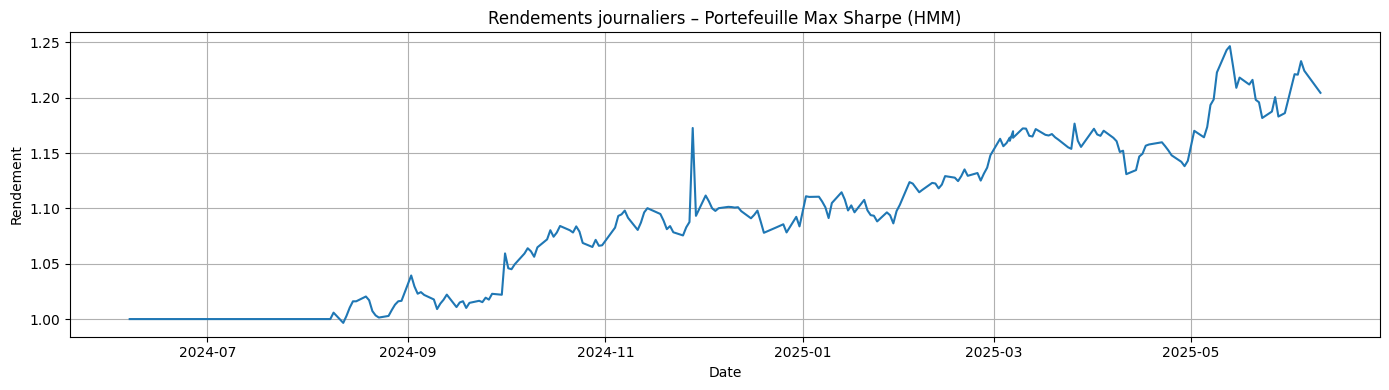

In [30]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_sharpe_hmm.index, df_backtest_sharpe_hmm['Valeur'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Max Sharpe (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

### Risque parity

In [ ]:
def risk_parity_weights(cov, max_iter=1000, tol=1e-6):
    n = cov.shape[0]
    w = np.ones(n) / n  # initialisation égalitaire

    for _ in range(max_iter):
        port_vol = np.sqrt(w.T @ cov @ w)
        marg_contrib = cov @ w
        risk_contrib = w * marg_contrib
        diff = risk_contrib - port_vol**2 / n
        grad = 2 * (diff * marg_contrib)

        w -= 0.01 * grad  # petit pas d’apprentissage
        w = np.maximum(w, 0)
        if np.sum(w) == 0:
            w = np.ones(n) / n
        w /= np.sum(w)

        if np.linalg.norm(diff) < tol:
            break

    return w


valeurs_rp = [1.0]
rendements_rp = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    debut_mois = (t - 1853) % 22 == 0

    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = risk_parity_weights(cov)

    if poids_actuels is None:
        rendements_rp.append(0)
        valeurs_rp.append(valeurs_rp[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_rp.append(rendement)
    valeurs_rp.append(valeurs_rp[-1] * (1 + rendement))

df_backtest_rp_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_rp,
    'Valeur': valeurs_rp[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)


In [33]:
df_backtest_rp_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.004812,0.890188
2025-06-03,-0.001877,0.888517
2025-06-04,0.003139,0.891307


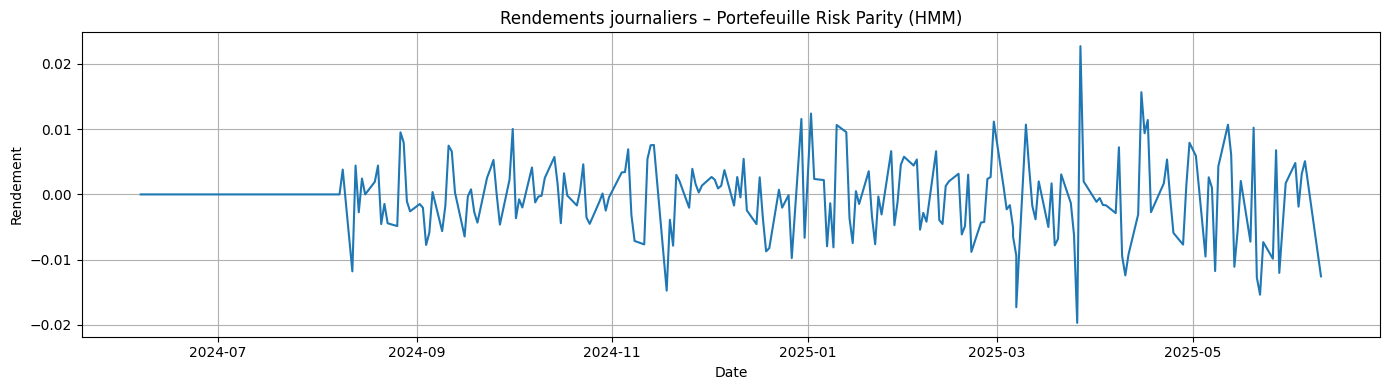

In [34]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_rp_hmm.index, df_backtest_rp_hmm['Rendement'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Risk Parity (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

### Max Diversification

In [ ]:
def max_diversification_portfolio(cov):
    sigma = np.sqrt(np.diag(cov))
    inv_vol = 1 / sigma
    w = inv_vol / np.sum(inv_vol)
    return w

valeurs_div = [1.0]
rendements_div = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    debut_mois = (t - 1853) % 22 == 0

    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = max_diversification_portfolio(cov)

    if poids_actuels is None:
        rendements_div.append(0)
        valeurs_div.append(valeurs_div[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_div.append(rendement)
    valeurs_div.append(valeurs_div[-1] * (1 + rendement))

df_backtest_div_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_div,
    'Valeur': valeurs_div[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [41]:
df_backtest_div_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.003372,0.864273
2025-06-03,-0.001635,0.862860
2025-06-04,0.002975,0.865427


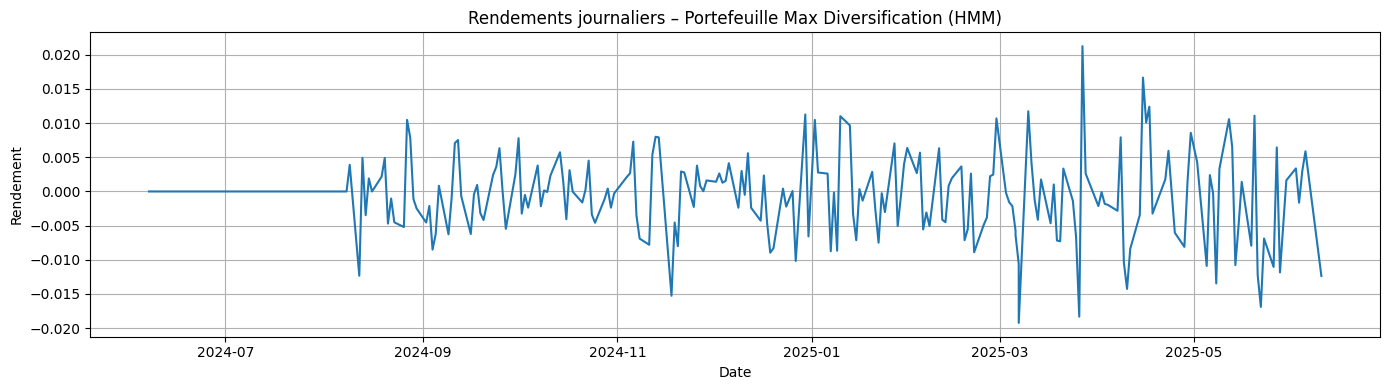

In [42]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_div_hmm.index, df_backtest_div_hmm['Rendement'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Max Diversification (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

### Min variance

In [ ]:
def min_variance_portfolio(cov):
    try:
        inv_cov = np.linalg.pinv(cov)
        w = np.sum(inv_cov, axis=1)
        w = np.maximum(w, 0)
        if np.sum(w) == 0 or np.any(np.isnan(w)):
            w = np.ones(len(cov)) / len(cov)
        else:
            w /= np.sum(w)
    except:
        w = np.ones(len(cov)) / len(cov)
    return w

valeurs_minvar = [1.0]
rendements_minvar = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    debut_mois = (t - 1853) % 22 == 0

    if debut_mois and t - 22 >= 1853:
        regime_mois_precedent = df_regimes_hmm_rt['Regime_confirme'].iloc[t-22-1853 : t-1853]
        changement = regime_mois_precedent.diff().fillna(0) != 0
        declencher = changement.any()
    else:
        declencher = False

    if declencher:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = min_variance_portfolio(cov)

    if poids_actuels is None:
        rendements_minvar.append(0)
        valeurs_minvar.append(valeurs_minvar[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_minvar.append(rendement)
    valeurs_minvar.append(valeurs_minvar[-1] * (1 + rendement))

df_backtest_minvar_hmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_minvar,
    'Valeur': valeurs_minvar[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [44]:
df_backtest_minvar_hmm

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.000527,0.861849
2025-06-03,-0.001391,0.860650
2025-06-04,0.002545,0.862840


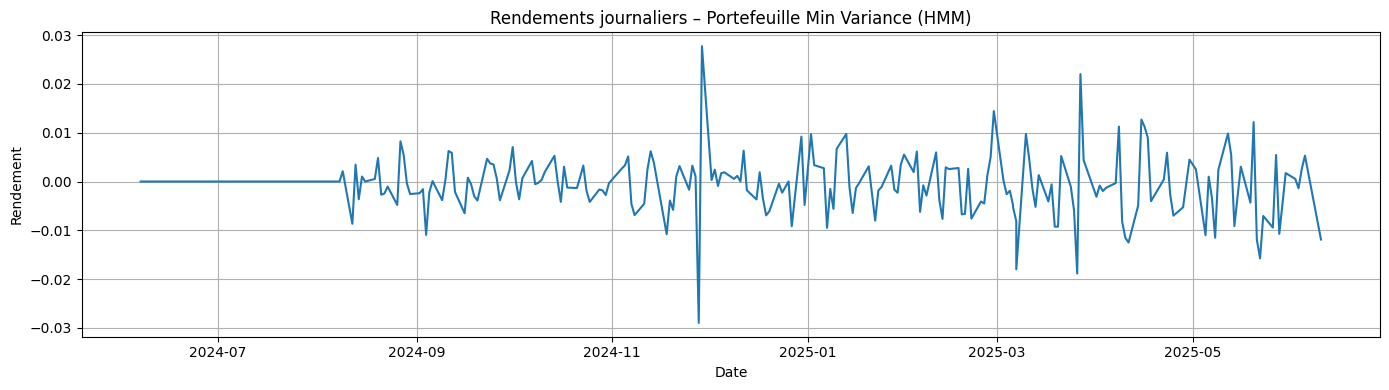

In [45]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_backtest_minvar_hmm.index, df_backtest_minvar_hmm['Rendement'], label='Rendement journalier')
plt.title("Rendements journaliers – Portefeuille Min Variance (HMM)")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.tight_layout()
plt.show()

## PHASE 4 : Construction des portefeuilles benchmarks

### MR Bench

In [ ]:
valeurs_mr_bench = [1.0]
rendements_mr_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    # Réallocation tous les 22 jours
    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        poids_actuels = mu / mu.sum()
        poids_actuels = np.clip(poids_actuels, 0, 0.8)
        poids_actuels /= poids_actuels.sum()  # Normalisation

    if poids_actuels is None:
        rendements_mr_bench.append(0)
        valeurs_mr_bench.append(valeurs_mr_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_mr_bench.append(rendement)
    valeurs_mr_bench.append(valeurs_mr_bench[-1] * (1 + rendement))

df_benchmark_mr = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_mr_bench,
    'Valeur': valeurs_mr_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)


In [47]:
df_benchmark_mr

,Rendement,Valeur
Date,,
2024-06-07,0.007675,1.007675
2024-06-10,0.003068,1.010767
2024-06-11,-0.006904,1.003789
2024-06-12,-0.004167,0.999606
2024-06-13,-0.012965,0.986646
...,...,...
2025-06-02,-0.003822,0.722847
2025-06-03,-0.004507,0.719589
2025-06-04,0.001629,0.720761


### Dyn Bench

In [ ]:
valeurs_dyn_bench = [1.0]
rendements_dyn_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        mu_abs = np.abs(mu)
        poids_actuels = mu_abs / mu_abs.sum()

    if poids_actuels is None:
        rendements_dyn_bench.append(0)
        valeurs_dyn_bench.append(valeurs_dyn_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_dyn_bench.append(rendement)
    valeurs_dyn_bench.append(valeurs_dyn_bench[-1] * (1 + rendement))

df_benchmark_dyn = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_dyn_bench,
    'Valeur': valeurs_dyn_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [49]:
df_benchmark_dyn

,Rendement,Valeur
Date,,
2024-06-07,0.005466,1.005466
2024-06-10,-0.002334,1.003119
2024-06-11,-0.005370,0.997732
2024-06-12,-0.003792,0.993949
2024-06-13,-0.008778,0.985225
...,...,...
2025-06-02,0.021085,1.085805
2025-06-03,-0.002352,1.083251
2025-06-04,0.007359,1.091223


### Sharpe Bench

In [ ]:
def max_sharpe_portfolio(mu, cov, rf=0.0):
    excess_returns = mu - rf
    try:
        inv_cov = np.linalg.pinv(cov)
        w = inv_cov @ excess_returns
        w = np.maximum(w, 0)
        if np.sum(w) == 0 or np.any(np.isnan(w)):
            w = np.ones_like(mu) / len(mu)
        else:
            w /= np.sum(w)
    except:
        w = np.ones_like(mu) / len(mu)
    return w


valeurs_sharpe_bench = [1.0]
rendements_sharpe_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        mu = sous_df.mean().values
        cov = sous_df.cov().values
        poids_actuels = max_sharpe_portfolio(mu, cov)

    if poids_actuels is None:
        rendements_sharpe_bench.append(0)
        valeurs_sharpe_bench.append(valeurs_sharpe_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_sharpe_bench.append(rendement)
    valeurs_sharpe_bench.append(valeurs_sharpe_bench[-1] * (1 + rendement))

df_benchmark_sharpe = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_sharpe_bench,
    'Valeur': valeurs_sharpe_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)


In [51]:
df_benchmark_sharpe

,Rendement,Valeur
Date,,
2024-06-07,0.002957,1.002957
2024-06-10,-0.000178,1.002778
2024-06-11,-0.005277,0.997486
2024-06-12,-0.002615,0.994877
2024-06-13,-0.003372,0.991522
...,...,...
2025-06-02,0.029672,1.234412
2025-06-03,-0.000542,1.233743
2025-06-04,0.009396,1.245335


### RP Bench

In [ ]:
def risk_parity_weights(cov, max_iter=1000, tol=1e-6):
    n = cov.shape[0]
    w = np.ones(n) / n

    for _ in range(max_iter):
        port_vol = np.sqrt(w.T @ cov @ w)
        marg_contrib = cov @ w
        risk_contrib = w * marg_contrib
        diff = risk_contrib - port_vol**2 / n
        grad = 2 * (diff * marg_contrib)

        w -= 0.01 * grad
        w = np.maximum(w, 0)
        if np.sum(w) == 0:
            w = np.ones(n) / n
        w /= np.sum(w)

        if np.linalg.norm(diff) < tol:
            break

    return w

valeurs_rp_bench = [1.0]
rendements_rp_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = risk_parity_weights(cov)

    if poids_actuels is None:
        rendements_rp_bench.append(0)
        valeurs_rp_bench.append(valeurs_rp_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_rp_bench.append(rendement)
    valeurs_rp_bench.append(valeurs_rp_bench[-1] * (1 + rendement))

df_benchmark_rp = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_rp_bench,
    'Valeur': valeurs_rp_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [53]:
df_benchmark_rp

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735


### MD Bench

In [ ]:
def max_diversification_portfolio(cov):
    sigma = np.sqrt(np.diag(cov))
    inv_vol = 1 / sigma
    w = inv_vol / np.sum(inv_vol)
    return w

valeurs_md_bench = [1.0]
rendements_md_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = max_diversification_portfolio(cov)

    if poids_actuels is None:
        rendements_md_bench.append(0)
        valeurs_md_bench.append(valeurs_md_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_md_bench.append(rendement)
    valeurs_md_bench.append(valeurs_md_bench[-1] * (1 + rendement))

df_benchmark_md = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_md_bench,
    'Valeur': valeurs_md_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [55]:
df_benchmark_md

,Rendement,Valeur
Date,,
2024-06-07,0.005046,1.005046
2024-06-10,0.001212,1.006265
2024-06-11,-0.004339,1.001899
2024-06-12,-0.003667,0.998225
2024-06-13,-0.007131,0.991106
...,...,...
2025-06-02,0.003448,0.827293
2025-06-03,-0.001662,0.825918
2025-06-04,0.003041,0.828430


### MV Bench

In [ ]:
def min_variance_portfolio(cov):
    try:
        inv_cov = np.linalg.pinv(cov)
        w = np.sum(inv_cov, axis=1)
        w = np.maximum(w, 0)
        if np.sum(w) == 0 or np.any(np.isnan(w)):
            w = np.ones(len(cov)) / len(cov)
        else:
            w /= np.sum(w)
    except:
        w = np.ones(len(cov)) / len(cov)
    return w

valeurs_mv_bench = [1.0]
rendements_mv_bench = []
poids_actuels = None

for t in range(1853, 2107):
    date = df.index[t]
    rendements_journaliers = df.iloc[t]

    if (t - 1853) % 22 == 0:
        sous_df = df.iloc[:t]
        cov = sous_df.cov().values
        poids_actuels = min_variance_portfolio(cov)

    if poids_actuels is None:
        rendements_mv_bench.append(0)
        valeurs_mv_bench.append(valeurs_mv_bench[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers.values
    rendements_mv_bench.append(rendement)
    valeurs_mv_bench.append(valeurs_mv_bench[-1] * (1 + rendement))

df_benchmark_mv = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_mv_bench,
    'Valeur': valeurs_mv_bench[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [57]:
df_benchmark_mv

,Rendement,Valeur
Date,,
2024-06-07,0.003131,1.003131
2024-06-10,0.001408,1.004543
2024-06-11,-0.004004,1.000521
2024-06-12,-0.003702,0.996817
2024-06-13,-0.004510,0.992321
...,...,...
2025-06-02,0.001167,0.832676
2025-06-03,-0.001164,0.831707
2025-06-04,0.002813,0.834046


### EQ : Équipondéré sur tous les facteurs

In [ ]:
poids_eq = np.ones(df.shape[1]) / df.shape[1]

valeurs_eq = [1.0]
rendements_eq = []

for t in range(1853, 2107):
    rendement = poids_eq @ df.iloc[t].values
    rendements_eq.append(rendement)
    valeurs_eq.append(valeurs_eq[-1] * (1 + rendement))

df_benchmark_eq = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_eq,
    'Valeur': valeurs_eq[1:]
}).set_index('Date')

# Afficher les pondérations de la dernière réallocation
dernieres_pondérations = poids_actuels
facteurs_utilisés = df.columns

# Créer un DataFrame lisible
df_pondérations_finales = pd.DataFrame({
    'Facteur': facteurs_utilisés,
    'Poids final': dernieres_pondérations
})

print("📊 Pondérations du portefeuille Sharpe HMM lors de la dernière réallocation :")
display(df_pondérations_finales)

In [59]:
df_benchmark_eq

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735


## PHASE 5 : Analyse des performances

###  Étape 1 : Regrouper les portefeuilles dans un seul DataFrame

In [60]:
portefeuilles = {
    "Max Return (HMM)": df_backtest_maxreturn_hmm['Valeur'],
    "Dynamique (HMM)": df_backtest_dyn_hmm['Valeur'],
    "Max Sharpe (HMM)": df_backtest_sharpe_hmm['Valeur'],
    "Risk Parity (HMM)": df_backtest_rp_hmm['Valeur'],
    "Max Diversification (HMM)": df_backtest_div_hmm['Valeur'],
    "Min Variance (HMM)": df_backtest_minvar_hmm['Valeur'],

    "MR Bench": df_benchmark_mr['Valeur'],
    "Dyn Bench": df_benchmark_dyn['Valeur'],
    "Sharpe Bench": df_benchmark_sharpe['Valeur'],
    "RP Bench": df_benchmark_rp['Valeur'],
    "MD Bench": df_benchmark_md['Valeur'],
    "MV Bench": df_benchmark_mv['Valeur'],
    "EQ": df_benchmark_eq['Valeur'],
}

df_comparaison = pd.DataFrame(portefeuilles)


In [61]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def performance_stats(df_valeurs, nom='Portefeuille'):
    rendements = df_valeurs.pct_change().dropna()
    rendement_moy = rendements.mean()
    volatilite = rendements.std()
    downside_risk = np.sqrt(np.mean(np.minimum(rendements, 0)**2))

    rendement_ann = rendement_moy * 254
    volatilite_ann = volatilite * np.sqrt(254)
    downside_risk_ann = downside_risk * np.sqrt(254)

    sharpe = rendement_ann / volatilite_ann
    sortino = rendement_ann / downside_risk_ann
    skewness = skew(rendements)
    kurt = kurtosis(rendements)

    valeur_cumulee = df_valeurs.values
    cumul_max = np.maximum.accumulate(valeur_cumulee)
    drawdowns = (valeur_cumulee - cumul_max) / cumul_max
    max_dd = drawdowns.min()
    dd_days = (drawdowns == max_dd).sum()

    return pd.Series({
        'Ann ret': rendement_ann,
        'Ann vol': volatilite_ann,
        'IR': sharpe,
        'Skw': skewness,
        'kurt': kurt,
        'D. risk': downside_risk_ann,
        'Sortino': sortino,
        'DD': max_dd,
        'DD days': dd_days
    }, name=nom)

tableau_resultats = pd.DataFrame()

tableau_resultats = pd.concat([
    performance_stats(df_backtest_maxreturn_hmm['Valeur'], "Max Return HMM"),
    performance_stats(df_backtest_dyn_hmm['Valeur'], "Dyn HMM"),
    performance_stats(df_backtest_sharpe_hmm['Valeur'], "Sharpe HMM"),
    performance_stats(df_backtest_rp_hmm['Valeur'], "RP HMM"),
    performance_stats(df_backtest_div_hmm['Valeur'], "MD HMM"),
    performance_stats(df_backtest_minvar_hmm['Valeur'], "MinVar HMM"),

    performance_stats(df_benchmark_mr['Valeur'], "MR Bench"),
    performance_stats(df_benchmark_dyn['Valeur'], "Dyn Bench"),
    performance_stats(df_benchmark_sharpe['Valeur'], "Sharpe Bench"),
    performance_stats(df_benchmark_rp['Valeur'], "RP Bench"),
    performance_stats(df_benchmark_md['Valeur'], "MD Bench"),
    performance_stats(df_benchmark_mv['Valeur'], "MV Bench"),
    performance_stats(df_benchmark_eq['Valeur'], "EQ"),
], axis=1).T

pd.set_option('display.float_format', lambda x: '%.4f' % x)
display(tableau_resultats)


,Ann ret,Ann vol,IR,Skw,kurt,D. risk,Sortino,DD,DD days
Max Return HMM,-0.2524,0.1319,-1.9141,-0.2193,1.8346,0.1045,-2.4150,-0.2405,1.0000
Dyn HMM,0.1009,0.1261,0.8003,0.6548,5.1471,0.0790,1.2769,-0.0653,1.0000
Sharpe HMM,0.1990,0.1569,1.2683,1.0181,23.4893,0.0953,2.0873,-0.0808,1.0000
RP HMM,-0.1190,0.0900,-1.3233,-0.0056,1.4817,0.0682,-1.7466,-0.1239,1.0000
MD HMM,-0.1475,0.0920,-1.6024,-0.0778,1.2803,0.0710,-2.0755,-0.1442,1.0000
MinVar HMM,-0.1505,0.0930,-1.6174,-0.0111,4.7673,0.0711,-2.1163,-0.1447,1.0000
MR Bench,-0.3251,0.1349,-2.4106,-0.1516,0.8277,0.1087,-2.9909,-0.2881,1.0000
Dyn Bench,0.0765,0.1327,0.5769,0.6824,2.4463,0.0832,0.9197,-0.0659,1.0000
Sharpe Bench,0.2078,0.1633,1.2726,0.9190,12.8354,0.0981,2.1196,-0.0729,1.0000
RP Bench,-0.1621,0.0954,-1.6995,0.0608,0.7414,0.0731,-2.2174,-0.1538,1.0000
